## Mumbai Property Dataset 
- Target variable : Super Buildup rate

### In this file following stuffs are implemented :
- Data understanding (Domain knownledge)
- Data cleaning 
- EDA
- Cleaned dataset is imported into new csv file


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./mumbai_property_data_with_TS.csv')

In [3]:
df.head()

,ID,Property Type,Address Area,Amenities,Property Age,Carpet Area (sq.ft.),Super Buildup Rate (per sq.ft.),Built-Up Area (sq.ft.),Area as per Approved Plan (sq.ft.),Valuation Area (sq.ft.),...,Last Sale Price (per sq.ft.),Last to Last Sale Price (per sq.ft.),Last Sale Year,Last to Last Sale Year,Property Name,Rate 2021 (per sq.ft.),Rate 2022 (per sq.ft.),Rate 2023 (per sq.ft.),Rate 2024 (per sq.ft.),Rate 2025 (per sq.ft.)
0,1,Residential,Borivali East,"Playground, Garden",15,709,21381.6,672,643,672,...,35606,35606,2011,2011,River Hts,18570,19885,18681,20138,21381.6
1,2,Residential,Borivali East,"Playground, Parking, Gym, Lift",6,1110,27342.0,1089,1067,1089,...,32697,32697,2020,2020,Moon Hights,27538,28632,30545,32100,27342.0
2,3,Residential,Malad East,"Garden, Swimming Pool",10,1130,26906.0,1102,1072,1102,...,24754,24754,2016,2016,Golden Vilas,24236,25576,23887,25103,26906.0
3,4,Residential,Juhu,"Playground, Garden, Lift",8,2166,57346.0,2120,2096,2120,...,53333,49114,2020,2018,Green Gdns,50907,54140,51208,54346,57346.0
4,5,Residential,Santacruz West,"Gym, Garden",3,2453,52827.0,2419,2403,2419,...,52791,52791,2023,2023,Santacruz West Res Apt,54514,57170,59357,51011,52827.0


In [4]:
df.shape

(10000, 29)

In [5]:
df.nunique()

ID                                        10000
Property Type                                 1
Address Area                                 11
Amenities                                   509
Property Age                                 14
Carpet Area (sq.ft.)                       2217
Super Buildup Rate (per sq.ft.)            9034
Built-Up Area (sq.ft.)                     2288
Area as per Approved Plan (sq.ft.)         2304
Valuation Area (sq.ft.)                    2288
Super Built-up Area (sq.ft.)               2457
Total Value (INR)                          9996
No of Car Parks                               3
Value of Car Park (INR)                       3
Final Value by Comparison Method (INR)     9999
Configuration                                 6
Condition                                     4
Landmark                                      6
Landmark Distance (KM)                       46
Last Sale Price (per sq.ft.)               9156
Last to Last Sale Price (per sq.ft.)    

- Property Type has 1 single value for all the records. 

In [6]:
df.isnull().sum()

ID                                        0
Property Type                             0
Address Area                              0
Amenities                                 0
Property Age                              0
Carpet Area (sq.ft.)                      0
Super Buildup Rate (per sq.ft.)           0
Built-Up Area (sq.ft.)                    0
Area as per Approved Plan (sq.ft.)        0
Valuation Area (sq.ft.)                   0
Super Built-up Area (sq.ft.)              0
Total Value (INR)                         0
No of Car Parks                           0
Value of Car Park (INR)                   0
Final Value by Comparison Method (INR)    0
Configuration                             0
Condition                                 0
Landmark                                  0
Landmark Distance (KM)                    0
Last Sale Price (per sq.ft.)              0
Last to Last Sale Price (per sq.ft.)      0
Last Sale Year                            0
Last to Last Sale Year          

- data is highly cleaned and contains no null values 

In [7]:
df.dtypes

ID                                          int64
Property Type                              object
Address Area                               object
Amenities                                  object
Property Age                                int64
Carpet Area (sq.ft.)                        int64
Super Buildup Rate (per sq.ft.)           float64
Built-Up Area (sq.ft.)                      int64
Area as per Approved Plan (sq.ft.)          int64
Valuation Area (sq.ft.)                     int64
Super Built-up Area (sq.ft.)                int64
Total Value (INR)                         float64
No of Car Parks                             int64
Value of Car Park (INR)                     int64
Final Value by Comparison Method (INR)    float64
Configuration                              object
Condition                                  object
Landmark                                   object
Landmark Distance (KM)                    float64
Last Sale Price (per sq.ft.)                int64


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10000.0,5.000500e+03,2.886896e+03,1.0,2500.75,5000.5,7.500250e+03,10000.0
Property Age,10000.0,8.470000e+00,4.006658e+00,2.0,5.00,8.0,1.200000e+01,15.0
Carpet Area (sq.ft.),10000.0,1.839297e+03,8.361042e+02,450.0,1149.00,2002.0,2.493250e+03,3500.0
Super Buildup Rate (per sq.ft.),10000.0,4.340103e+04,1.978112e+04,19920.8,28271.00,38963.0,5.321800e+04,118204.0
Built-Up Area (sq.ft.),10000.0,1.804347e+03,8.361748e+02,401.0,1113.00,1960.5,2.459250e+03,3468.0
Area as per Approved Plan (sq.ft.),10000.0,1.784404e+03,8.362242e+02,376.0,1093.00,1936.5,2.439000e+03,3450.0
Valuation Area (sq.ft.),10000.0,1.804347e+03,8.361748e+02,401.0,1113.00,1960.5,2.459250e+03,3468.0
Super Built-up Area (sq.ft.),10000.0,1.989247e+03,8.367105e+02,551.0,1298.00,2118.0,2.647000e+03,3698.0
Total Value (INR),10000.0,8.716170e+07,7.307742e+07,8364347.2,33217127.50,61696140.0,1.205506e+08,403603928.0
No of Car Parks,10000.0,1.991500e+00,8.172482e-01,1.0,1.00,2.0,3.000000e+00,3.0


In [11]:
df.describe(include='object').T

,count,unique,top,freq
Property Type,10000,1,Residential,10000
Address Area,10000,11,Santacruz West,966
Amenities,10000,509,"Garden, Swimming Pool",133
Configuration,10000,6,4BHK,1718
Condition,10000,4,Fair,3568
Landmark,10000,6,Hotel,1713
Property Name,10000,1006,Santacruz West Twrs,43


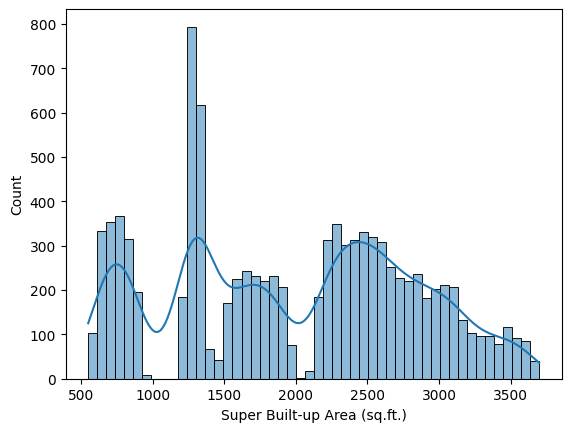

In [17]:
sns.histplot(df['Super Built-up Area (sq.ft.)'], bins=50, kde=True)
plt.show()

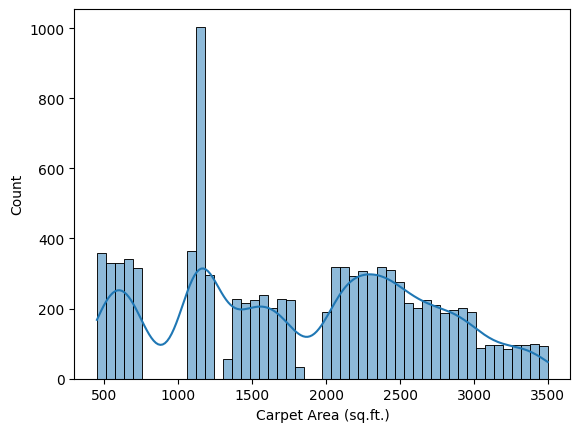

In [18]:
sns.histplot(df['Carpet Area (sq.ft.)'], bins=50, kde=True)
plt.show()

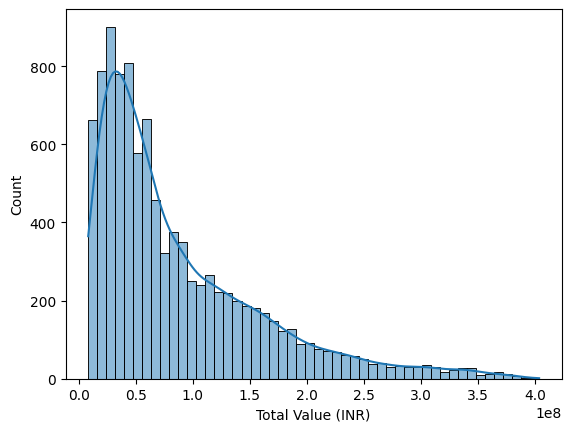

In [34]:
sns.histplot(df['Total Value (INR)'], bins=50, kde=True)
plt.show()

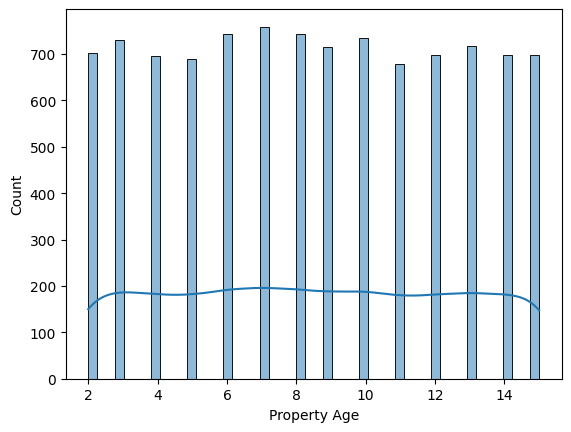

In [21]:
sns.histplot(df['Property Age'], bins=50, kde=True)
plt.show()

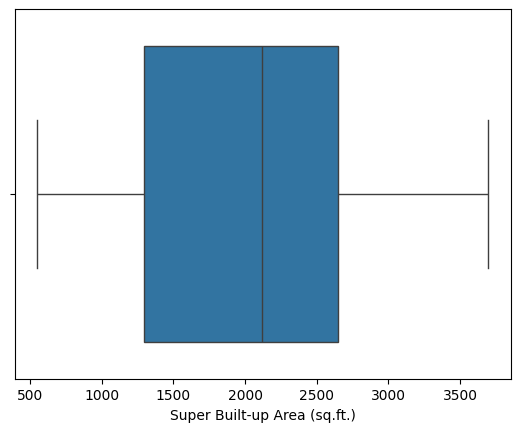

In [19]:
sns.boxplot(x=df['Super Built-up Area (sq.ft.)'])
plt.show()

In [23]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df.head()

,ID,Property Age,Carpet Area (sq.ft.),Super Buildup Rate (per sq.ft.),Built-Up Area (sq.ft.),Area as per Approved Plan (sq.ft.),Valuation Area (sq.ft.),Super Built-up Area (sq.ft.),Total Value (INR),No of Car Parks,...,Landmark Distance (KM),Last Sale Price (per sq.ft.),Last to Last Sale Price (per sq.ft.),Last Sale Year,Last to Last Sale Year,Rate 2021 (per sq.ft.),Rate 2022 (per sq.ft.),Rate 2023 (per sq.ft.),Rate 2024 (per sq.ft.),Rate 2025 (per sq.ft.)
0,1,15,709,21381.6,672,643,672,811,14368435.2,2,...,1.1,35606,35606,2011,2011,18570,19885,18681,20138,21381.6
1,2,6,1110,27342.0,1089,1067,1089,1228,29775438.0,2,...,4.8,32697,32697,2020,2020,27538,28632,30545,32100,27342.0
2,3,10,1130,26906.0,1102,1072,1102,1298,29650412.0,2,...,3.8,24754,24754,2016,2016,24236,25576,23887,25103,26906.0
3,4,8,2166,57346.0,2120,2096,2120,2300,121573520.0,3,...,1.2,53333,49114,2020,2018,50907,54140,51208,54346,57346.0
4,5,3,2453,52827.0,2419,2403,2419,2649,127788513.0,1,...,1.1,52791,52791,2023,2023,54514,57170,59357,51011,52827.0


In [25]:
numerical_df.corr()

,ID,Property Age,Carpet Area (sq.ft.),Super Buildup Rate (per sq.ft.),Built-Up Area (sq.ft.),Area as per Approved Plan (sq.ft.),Valuation Area (sq.ft.),Super Built-up Area (sq.ft.),Total Value (INR),No of Car Parks,...,Landmark Distance (KM),Last Sale Price (per sq.ft.),Last to Last Sale Price (per sq.ft.),Last Sale Year,Last to Last Sale Year,Rate 2021 (per sq.ft.),Rate 2022 (per sq.ft.),Rate 2023 (per sq.ft.),Rate 2024 (per sq.ft.),Rate 2025 (per sq.ft.)
ID,1.000000,0.013467,-0.017001,-0.012296,-0.017054,-0.017099,-0.017054,-0.017115,-0.015598,0.013583,...,0.002085,-0.009168,-0.008143,-0.016555,-0.014215,-0.012044,-0.011871,-0.012277,-0.011638,-0.012296
Property Age,0.013467,1.000000,-0.001978,-0.199626,-0.001966,-0.001994,-0.001966,-0.001847,-0.109672,0.020004,...,0.008226,-0.177115,-0.173690,-0.636044,-0.871741,-0.200016,-0.198063,-0.197923,-0.197013,-0.199626
Carpet Area (sq.ft.),-0.017001,-0.001978,1.000000,0.535390,0.999943,0.999917,0.999943,0.999395,0.813991,0.004799,...,-0.006587,0.509351,0.501162,-0.014213,-0.008774,0.532284,0.526575,0.525825,0.526071,0.535390
Super Buildup Rate (per sq.ft.),-0.012296,-0.199626,0.535390,1.000000,0.535177,0.535208,0.535177,0.535129,0.899447,-0.001381,...,-0.015671,0.944749,0.930604,0.123246,0.169126,0.995376,0.983738,0.979741,0.984063,1.000000
Built-Up Area (sq.ft.),-0.017054,-0.001966,0.999943,0.535177,1.000000,0.999974,1.000000,0.999333,0.813901,0.005027,...,-0.006755,0.509208,0.501037,-0.014159,-0.008835,0.532083,0.526388,0.525625,0.525872,0.535177
Area as per Approved Plan (sq.ft.),-0.017099,-0.001994,0.999917,0.535208,0.999974,1.000000,0.999974,0.999307,0.813873,0.004996,...,-0.006836,0.509220,0.501063,-0.014062,-0.008756,0.532118,0.526412,0.525667,0.525912,0.535208
Valuation Area (sq.ft.),-0.017054,-0.001966,0.999943,0.535177,1.000000,0.999974,1.000000,0.999333,0.813901,0.005027,...,-0.006755,0.509208,0.501037,-0.014159,-0.008835,0.532083,0.526388,0.525625,0.525872,0.535177
Super Built-up Area (sq.ft.),-0.017115,-0.001847,0.999395,0.535129,0.999333,0.999307,0.999333,1.000000,0.813564,0.003849,...,-0.006180,0.509012,0.500886,-0.014395,-0.008830,0.531995,0.526340,0.525606,0.525854,0.535129
Total Value (INR),-0.015598,-0.109672,0.813991,0.899447,0.813901,0.813873,0.813901,0.813564,1.000000,0.003237,...,-0.013024,0.850810,0.837307,0.062265,0.087488,0.895127,0.884693,0.881964,0.885017,0.899447
No of Car Parks,0.013583,0.020004,0.004799,-0.001381,0.005027,0.004996,0.005027,0.003849,0.003237,1.000000,...,0.003172,-0.004835,-0.004955,-0.018422,-0.016128,0.000688,0.000120,-0.003431,-0.003398,-0.001381


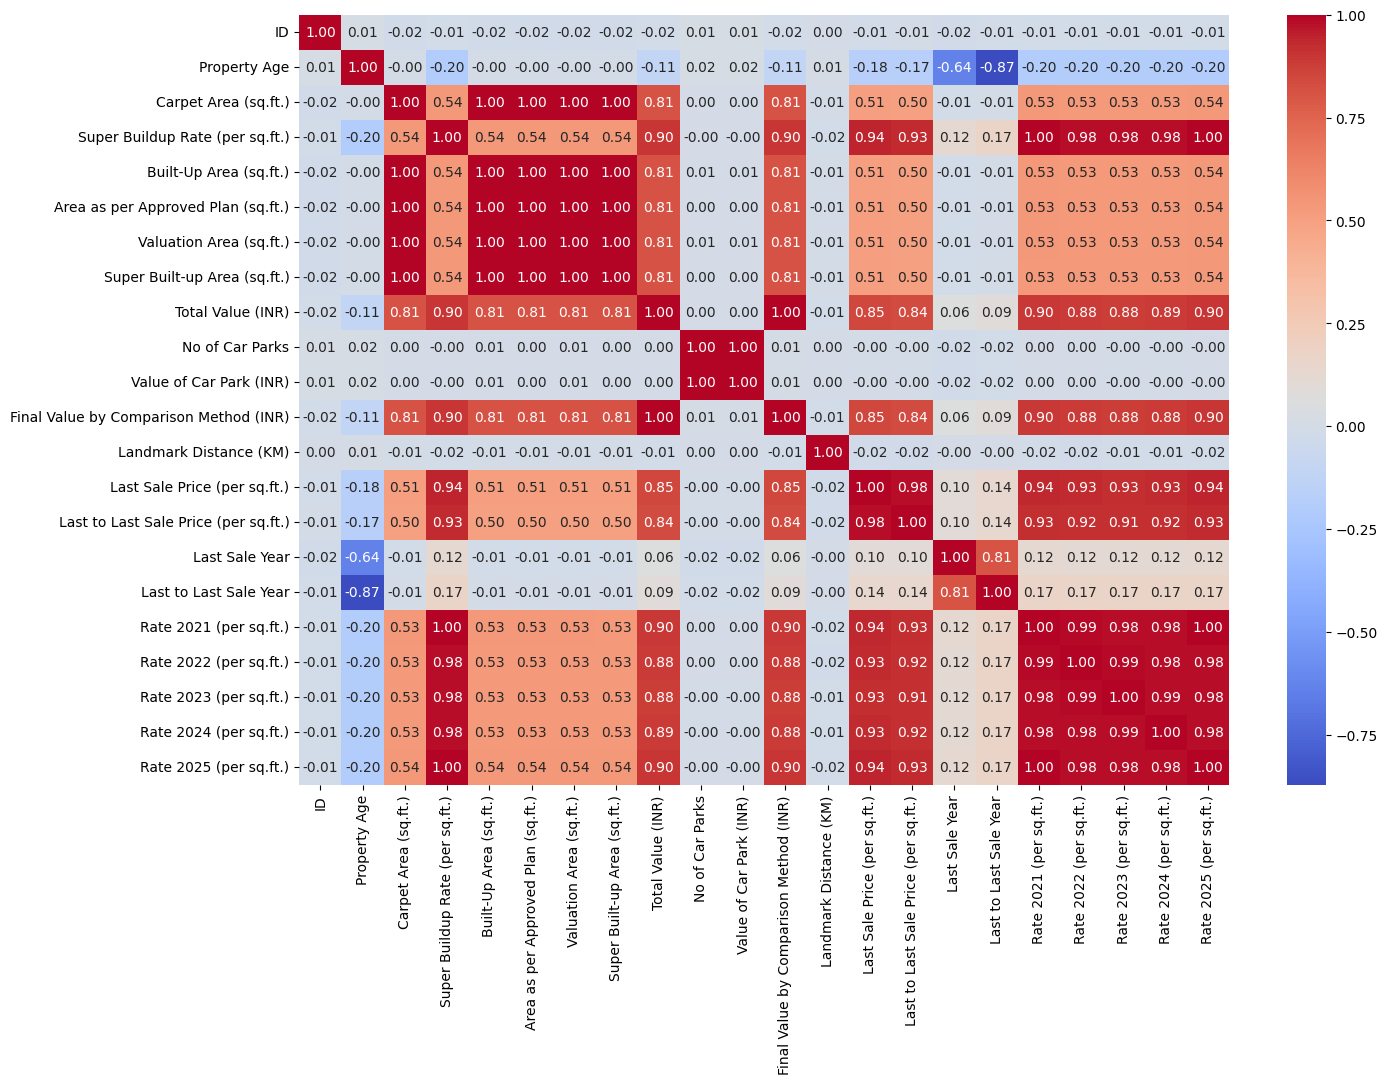

In [28]:
fig=plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

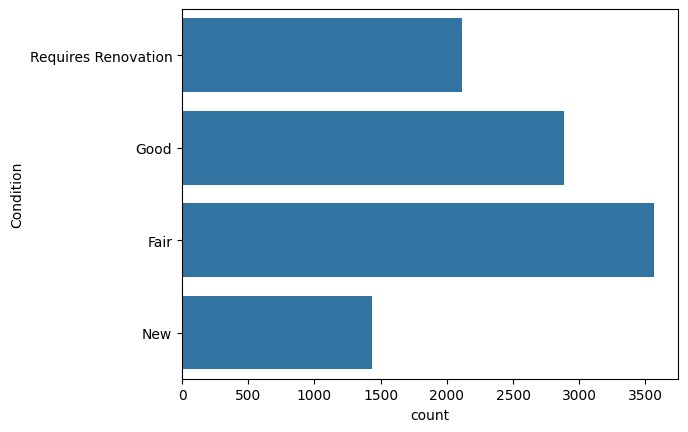

In [31]:
sns.countplot(data=df['Condition'])
plt.show()

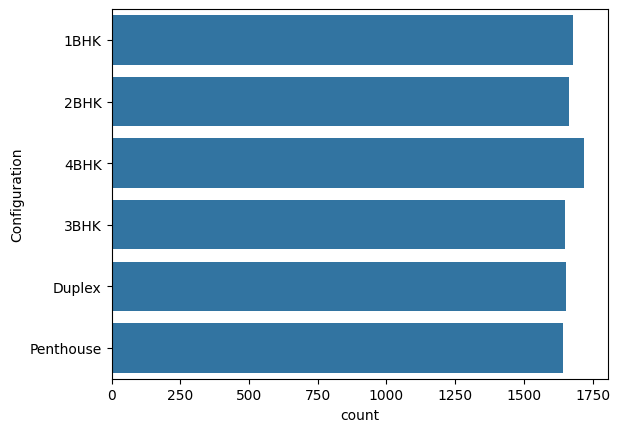

In [32]:
sns.countplot(data=df['Configuration'])
plt.show()

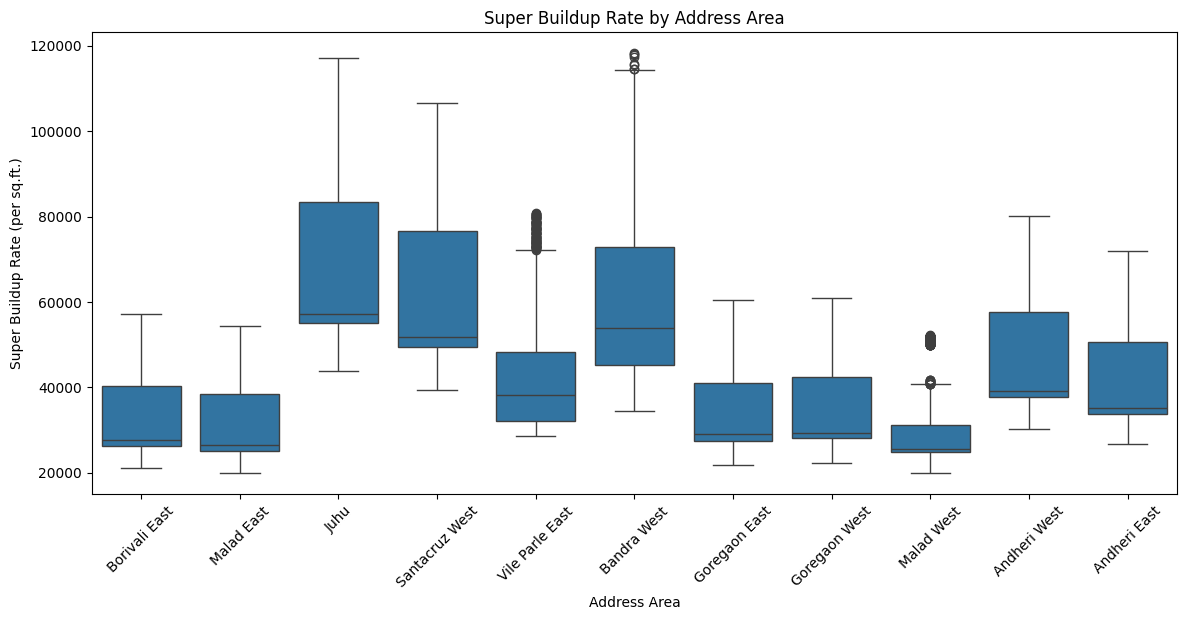

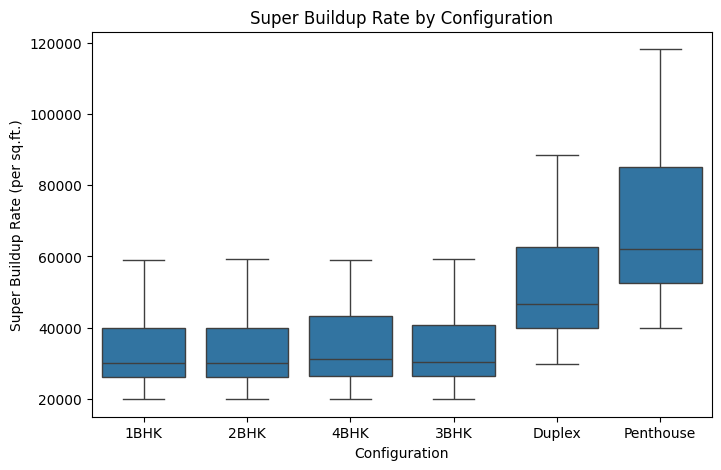

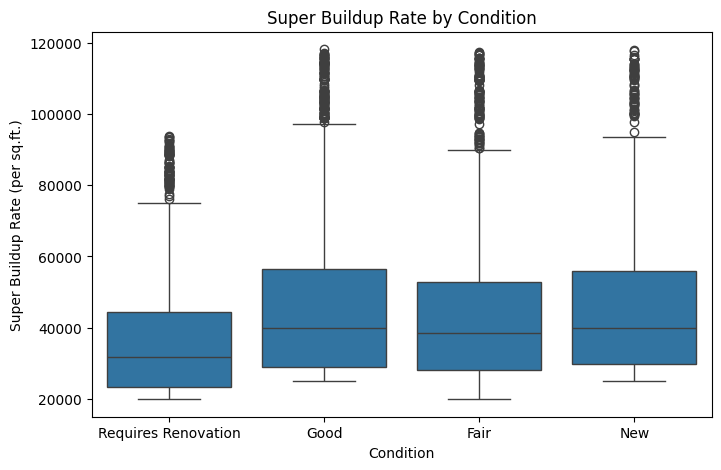

In [35]:
# Variation across Address Area
plt.figure(figsize=(14,6))
sns.boxplot(x='Address Area', y='Super Buildup Rate (per sq.ft.)', data=df)
plt.xticks(rotation=45)
plt.title('Super Buildup Rate by Address Area')
plt.show()

# Variation across Configuration
plt.figure(figsize=(8,5))
sns.boxplot(x='Configuration', y='Super Buildup Rate (per sq.ft.)', data=df)
plt.title('Super Buildup Rate by Configuration')
plt.show()

# Variation across Condition
plt.figure(figsize=(8,5))
sns.boxplot(x='Condition', y='Super Buildup Rate (per sq.ft.)', data=df)
plt.title('Super Buildup Rate by Condition')
plt.show()

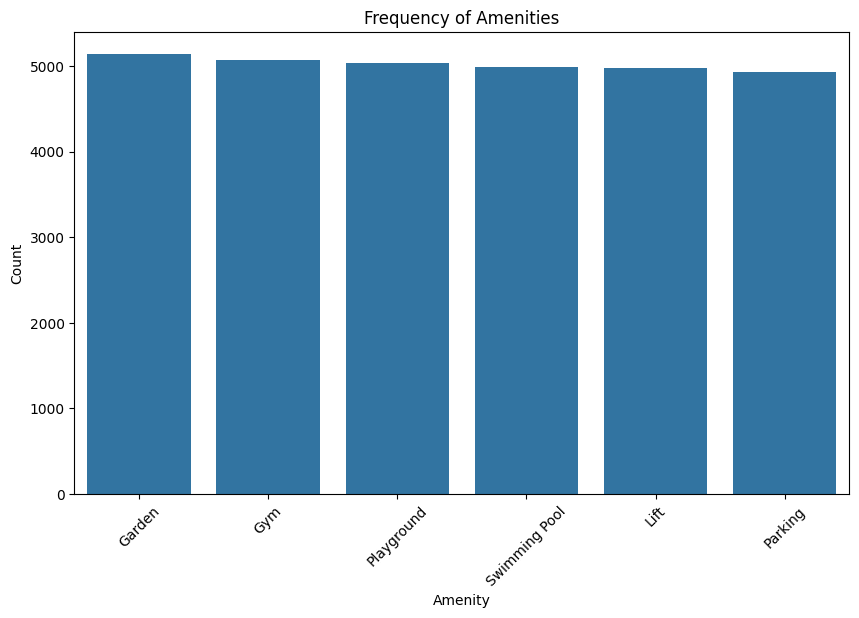

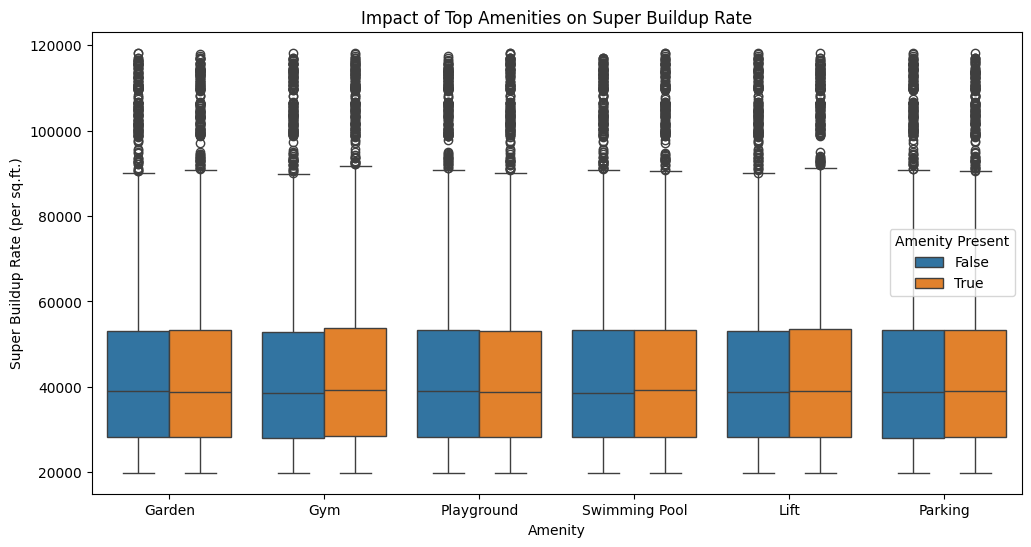

In [37]:
# Analyze frequency of amenities
from collections import Counter

# Split amenities and count frequency
amenities_list = df['Amenities'].str.split(', ')
amenities_flat = [item for sublist in amenities_list for item in sublist]
amenity_counts = pd.Series(Counter(amenities_flat)).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=amenity_counts.index, y=amenity_counts.values)
plt.xticks(rotation=45)
plt.title('Frequency of Amenities')
plt.ylabel('Count')
plt.xlabel('Amenity')
plt.show()

# Check impact of specific amenities on Super Buildup Rate
# Create binary columns for top amenities
top_amenities = amenity_counts.index[:6]  # Select top 6 amenities for visualization
for amenity in top_amenities:
    df[amenity] = df['Amenities'].apply(lambda x: amenity in x)

plt.figure(figsize=(12,6))
sns.boxplot(data=pd.melt(df, id_vars=['Super Buildup Rate (per sq.ft.)'], value_vars=top_amenities),
            x='variable', y='Super Buildup Rate (per sq.ft.)', hue='value')
plt.title('Impact of Top Amenities on Super Buildup Rate')
plt.xlabel('Amenity')
plt.ylabel('Super Buildup Rate (per sq.ft.)')
plt.legend(title='Amenity Present')
plt.show()

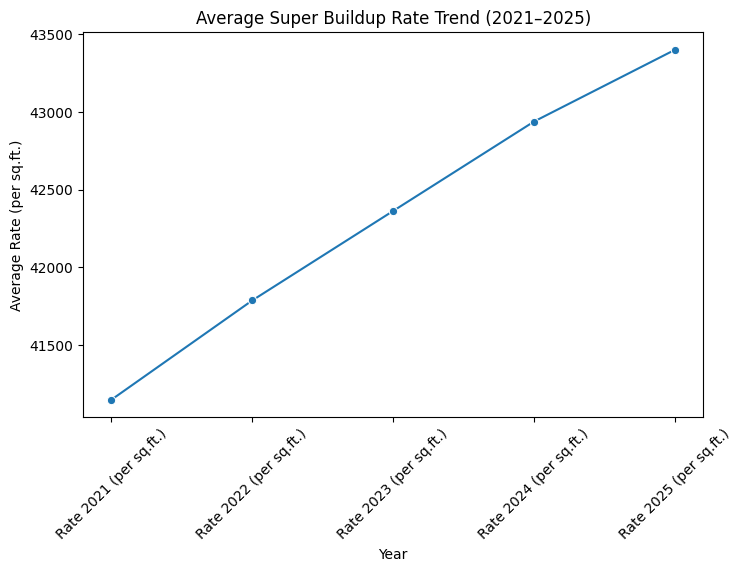

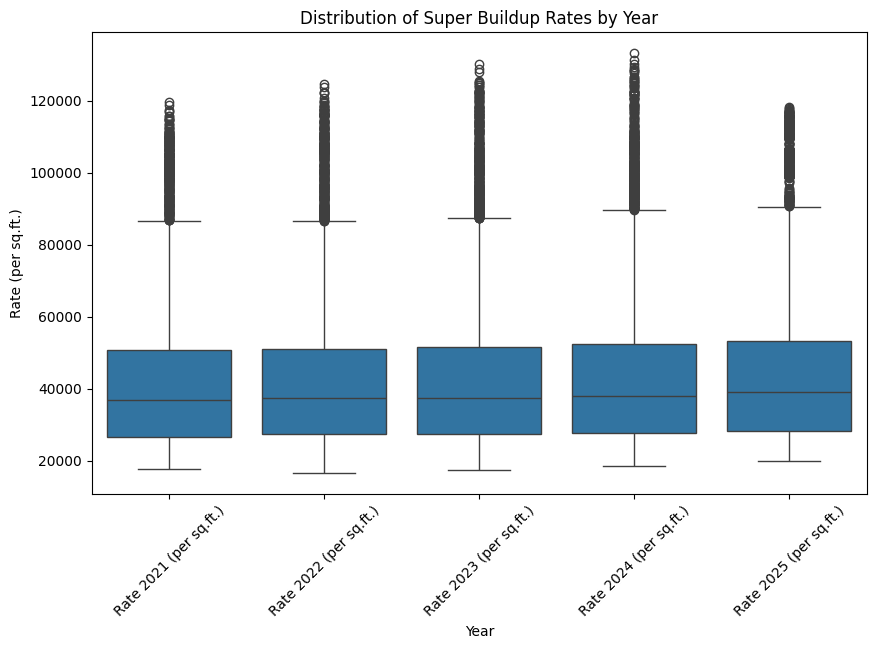

In [38]:
# Plot historical rates (Rate 2021–2025) to visualize trends

rate_cols = ['Rate 2021 (per sq.ft.)', 'Rate 2022 (per sq.ft.)', 'Rate 2023 (per sq.ft.)', 'Rate 2024 (per sq.ft.)', 'Rate 2025 (per sq.ft.)']

# Line plot for average rate per year
avg_rates = df[rate_cols].mean()
plt.figure(figsize=(8,5))
sns.lineplot(x=avg_rates.index, y=avg_rates.values, marker='o')
plt.title('Average Super Buildup Rate Trend (2021–2025)')
plt.ylabel('Average Rate (per sq.ft.)')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

# Boxplot for distribution of rates per year
df_melted = df.melt(value_vars=rate_cols, var_name='Year', value_name='Rate (per sq.ft.)')
plt.figure(figsize=(10,6))
sns.boxplot(x='Year', y='Rate (per sq.ft.)', data=df_melted)
plt.title('Distribution of Super Buildup Rates by Year')
plt.ylabel('Rate (per sq.ft.)')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()